In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import chess
import chess.svg
import json
import math
import cv2
from pathlib import Path
from IPython.display import display, SVG, HTML

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 512
RESULTS_DIR = Path("experiments/results")
MODEL_DIR = Path("models")

In [ ]:
"""
Notes: 
We only use positions that do not mix in too much domain knowledge, we want the examples to be very clear and obvious
Check turn bit and pull actual white/black gradients to see why important square lights up

Narrative: 
CNN stable but cannot spot tactics as good as transformers due to inherent convolution so it often thinks the position is more balanced than it is, aka, cnn evaluates the pieces as is without noticing "extra" interaction/tactics between them
Transformers good at spotting tactics, find nice forced mates/forks/pins, but sometimes miss the big picture, making the CNN/MLP's inablility to spot these tactics and guessing balanced/opposite look correct (Spurious Success)
MLP generally just counts pieces and thats why it fails

Transformer Win and CNN Failure
Skewer/Pin > 2R5/8/k7/4K3/8/8/r7/8 b - - 0 1

CNN Win and Transformer Failure
Attention Hijacking > 2r3k1/7p/p5p1/1pN2p2/1P6/P7/1Bp2PPP/3qQ1K1 w - - 0 1
"""

In [184]:
# ==========================================
# Configuration
# ==========================================
class Config:
    ACTIVE_MODELS = ["MLP", "CNN", "TRANSFORMER_4H"] 
    
    # 'FEN' / 'DATASET'
    TEST_MODE = "FEN" 

    # Main Fork: 2r2r2/2p1qpk1/p1np3p/1p4p1/4P3/Q3N1bP/P2K2P1/2R2B2 w - - 0 1 | ["MLP", "CNN", "TRANSFORMER_8H"] 
    # Failure Analysis Skewer: R7/6p1/2k3qp/8/8/8/2P3P1/2K5 w - - 0 1 | ["MLP", "CNN", "TRANSFORMER_8H"] 

    # --- Change if TEST_MODE = "FEN" ---
    FEN_STRING = "kr6/pp6/8/3N4/4n3/8/6PP/6RK b - - 0 1"
    TRUE_LABEL_FOR_FEN = 0
    
    # --- Change if TEST_MODE = "DATASET" ---
    ERROR_MAGNITUDE = "0" 
    IDX_IN_LIST = 2 

    # Toggle to save space
    SHOW_GRADIENTS = True
    
MODEL_REGISTRY = {
    "CNN": {
        "name": "seresnet_new_v2_16",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "seresnet_new_v2_16_all_indices.json"
    },
    "MLP": {
        "name": "probs_mlp_v4",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "index_file": "run_2026_01_22_probs_mlp_v4_all_indices.json"
    },
    "TRANSFORMER_4H": {
        "name": "transformer_v1",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "transformer_v1_all_indices.json"
    },
    "TRANSFORMER_8H": {
        "name": "transformer_v2",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "transformer_v2_failure_indices.json"
    },
    "CNN_PROBE": {
        "name": "seresnet_v2_16_probe",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "seresnet_new_v1_16_probe_failure_indices.json"
    },
    "MLP_PROBE": {
        "name": "probs_mlp_v4_probe",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "index_file": "probs_mlp_v4_probe_failure_indices.json"
    },
    "TRANSFORMER_4H_PROBE": {
        "name": "transformer_v1_probe",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "index_file": "transformer_v1_probe_failure_indices.json"
    }
}

In [3]:
# ==========================================
# Utility Functions
# ==========================================
def sanitize_fen_for_filename(fen: str) -> str:
    return fen.replace("/", "-").replace(" ", "_")

def tensor_to_fen(tensor):
    index_to_piece = {0:'P', 1:'N', 2:'B', 3:'R', 4:'Q', 5:'K', 
                      6:'p', 7:'n', 8:'b', 9:'r', 10:'q', 11:'k'}
    board = chess.Board(None)
    for piece_idx in range(12):
        for row in range(8):
            for col in range(8):
                if tensor[piece_idx, row, col] == 1:
                    board.set_piece_at(chess.square(col, row), chess.Piece.from_symbol(index_to_piece[piece_idx]))

    board.turn = chess.WHITE if tensor[12, 0, 0] == 1 else chess.BLACK
    castling_fen = ""
    if tensor[13, 0, 0] == 1: castling_fen += "K"
    if tensor[14, 0, 0] == 1: castling_fen += "Q"
    if tensor[15, 0, 0] == 1: castling_fen += "k"
    if tensor[16, 0, 0] == 1: castling_fen += "q"
    board.set_castling_fen(castling_fen if castling_fen else "-")

    ep_rows, ep_cols = np.where(tensor[18] == 1)
    if len(ep_rows) > 0:
        board.ep_square = chess.square(ep_cols[0], ep_rows[0])
    return board.fen()

def fen_to_tensor(fen):
    board = chess.Board(fen)
    tensor = np.zeros((19, 8, 8), dtype=np.float32)
    piece_to_channel = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        row, col = divmod(square, 8)
        tensor[piece_to_channel[piece.symbol()], row, col] = 1
    
    if board.turn == chess.WHITE: tensor[12, :, :] = 1
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, :, :] = 1
    if board.has_queenside_castling_rights(chess.WHITE): tensor[14, :, :] = 1
    if board.has_kingside_castling_rights(chess.BLACK): tensor[15, :, :] = 1
    if board.has_queenside_castling_rights(chess.BLACK): tensor[16, :, :] = 1
    if board.is_check(): tensor[17, :, :] = 1
    if board.ep_square is not None:
        row, col = divmod(board.ep_square, 8)
        tensor[18, row, col] = 1
    return tensor

def vector_to_fen(vector):
    index_to_piece = {0:'P', 1:'N', 2:'B', 3:'R', 4:'Q', 5:'K', 6:'p', 7:'n', 8:'b', 9:'r', 10:'q', 11:'k'}
    board = chess.Board(None) 
    for piece_idx in range(12):
        for square in range(64):
            if vector[piece_idx * 64 + square] == 1:
                board.set_piece_at(square, chess.Piece.from_symbol(index_to_piece[piece_idx]))
                
    board.turn = chess.WHITE if vector[768] == 1 else chess.BLACK
    castling_fen = ""
    if vector[769] == 1: castling_fen += "K"
    if vector[770] == 1: castling_fen += "Q"
    if vector[771] == 1: castling_fen += "k"
    if vector[772] == 1: castling_fen += "q"
    board.set_castling_fen(castling_fen if castling_fen else "-")
    return board.fen()

def fen_to_vector(fen):
    board = chess.Board(fen)
    vector = np.zeros(775, dtype=np.float32)
    piece_to_idx = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        vector[piece_to_idx[piece.symbol()] * 64 + square] = 1
        
    if board.turn == chess.WHITE: vector[768] = 1
    if board.has_kingside_castling_rights(chess.WHITE): vector[769] = 1
    if board.has_queenside_castling_rights(chess.WHITE): vector[770] = 1
    if board.has_kingside_castling_rights(chess.BLACK): vector[771] = 1
    if board.has_queenside_castling_rights(chess.BLACK): vector[772] = 1
    return vector

In [4]:
# ==========================================
# Dataset & Architectures
# ==========================================
class ChessDataset(Dataset):
    def __init__(self, root_dir: Path, split: str):
        self.X = np.load(root_dir / f"{split}_X.npy", mmap_mode='r')
        self.y = np.load(root_dir / f"{split}_y.npy", mmap_mode='r')

    def __len__(self): return self.X.shape[0]
    
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# --- MLP ---
class MLP(nn.Module):
    def __init__(self, input_shape=775, output_shape=7):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_shape, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, output_shape)
        )
    def forward(self, x): return self.network(x)

# --- CNN ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.mlp(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        return x.div(keep_prob) * random_tensor

class ResidualBlock(nn.Module):
    def __init__(self, channels, drop_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1, self.bn2 = nn.BatchNorm2d(channels), nn.BatchNorm2d(channels)
        self.relu, self.se = nn.ReLU(), SEBlock(channels, reduction=8)
        self.drop_path = DropPath(drop_prob) if drop_prob > 0. else nn.Identity()
    def forward(self, x):
        identity = x 
        x = self.se(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))
        return self.relu(self.drop_path(x) + identity)

class SEResNet(nn.Module):
    def __init__(self, in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0):
        super().__init__()
        self.initialconv = nn.Sequential(
            nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU()
        )
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_blocks)]
        self.res_tower = nn.Sequential(*[ResidualBlock(channels, drop_prob=dpr[i]) for i in range(num_blocks)])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(32, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.bottleneck(self.res_tower(self.initialconv(x))))

# --- TRANSFORMER ---
class Ffn(nn.Module):
    def __init__(self, embed_dim, ffn_dim):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ffn_dim)
        self.activation = nn.ReLU() 
        self.linear2 = nn.Linear(ffn_dim, embed_dim)
    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, num_blocks):
        super().__init__()
        self.alpha = math.pow(2.0 * num_blocks, -0.25)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(embed_dim), nn.LayerNorm(embed_dim)
        self.ffn = Ffn(embed_dim, ffn_dim)
    def forward(self, x):
        attn_out, _ = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = x + attn_out * self.alpha
        identity = self.ln1(x)
        x = identity + self.ffn(identity) * self.alpha
        return self.ln2(x)

class Transformer(nn.Module):
    def __init__(self, input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7):
        super().__init__()
        self.embedding = nn.Linear(input_channels, embed_dim)
        self.embed_activation = nn.ReLU()
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 64, embed_dim))
        nn.init.normal_(self.pos_embedding, mean=0, std=0.02)
        
        self.blocks = nn.ModuleList([EncoderBlock(embed_dim, num_heads, ffn_dim, num_blocks) for _ in range(num_blocks)])
        self.classifier_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.ReLU(), nn.Linear(embed_dim // 2, num_classes)
        )
    def forward(self, x):
        x = x.permute(0, 2, 3, 1).flatten(1, 2)
        x = self.embed_norm(self.embed_activation(self.embedding(x))) + self.pos_embedding
        for block in self.blocks: x = block(x)
        return self.classifier_head(x.mean(dim=1))

In [5]:
# ==========================================
# Visualization
# ==========================================
def save_chess_board_svg(fen, save_name, size=350):
    """
    Generates an SVG image of a chess board from a FEN string and saves it.
    """
    if not save_name.endswith('.svg'):
        save_name += '.svg'
    board = chess.Board(fen)
    board_svg = chess.svg.board(board, size=size)
    with open(save_name, "w") as f:
        f.write(board_svg)
    print(f"Board successfully saved to {save_name}")

def display_side_by_side(svgs, titles):
    """Helper to display multiple SVGs horizontally using HTML flexbox."""
    html_str = '<div style="display: flex; justify-content: center; gap: 20px; text-align: center; margin-bottom: 20px;">'
    for svg, title in zip(svgs, titles):
        html_str += f'<div><h4 style="margin-bottom: 5px;">{title}</h4>{svg}</div>'
    html_str += '</div>'
    display(HTML(html_str))
    
def render_heatmap_svg(saliency_64, fen_str, title, display_svg=True):
    """
    Helper function to normalize a 64-element array and draw the chessboard.
    Returns board_svg for easy saving. 
    """
    # Normalize between 0.0 and 1.0
    sal_min, sal_max = np.min(saliency_64), np.max(saliency_64)
    if sal_max > sal_min:
        saliency_norm = (saliency_64 - sal_min) / (sal_max - sal_min)
    else:
        saliency_norm = saliency_64

    cmap = plt.get_cmap("viridis")
    fill_dict = {i: mcolors.to_hex(cmap(saliency_norm[i]), keep_alpha=False) for i in range(64)}
    
    for square_idx in range(64):
        val = saliency_norm[square_idx]
        rgba = cmap(val)
        hex_color = mcolors.to_hex(rgba, keep_alpha=False)
        fill_dict[square_idx] = hex_color

    board_svg = chess.svg.board(
        chess.Board(fen_str),
        fill=fill_dict,
        size=300,
        coordinates=False,
        style=".square { stroke: white; stroke-width: 1.5px; }"
    )
    
    if display_svg:
        print(title)
        display(SVG(board_svg))

    return board_svg

class SaliencyExtractor:
    def __init__(self, model):
        self.model = model.eval()
        
    def generate_saliency(self, input_tensor, target_class):
        self.model.zero_grad()
        input_tensor.requires_grad = True
        
        preds = self.model(input_tensor)
        score = preds[0, target_class]
        score.backward()
        
        grads = input_tensor.grad.data.cpu().numpy()[0]
        if len(grads.shape) == 3: # Flatten 3D tensors cleanly inside the class
            grads = grads.flatten()
        return grads

def plot_chess_gradients(gradients):
    fig, ax1 = plt.subplots(figsize=(15, 6))
    ax1.plot(gradients, color="b", linewidth=1, label='Gradient Magnitude')
    channels = ['P', 'N', 'B', 'R', 'Q', 'K', 'p', 'n', 'b', 'r', 'q', 'k']
    
    y_min, y_max = np.min(gradients), np.max(gradients)
    y_range = y_max - y_min
    text_y_pos = y_max + (y_range * 0.05) 
    
    for i, channel in enumerate(channels):
        start_idx, end_idx = i * 64, (i + 1) * 64
        if i % 2 == 0:
            ax1.axvspan(start_idx, end_idx, color='gray', alpha=0.1, lw=0)
        ax1.axvline(x=end_idx, color='gray', linestyle=':', alpha=0.5)
        ax1.text(start_idx + 32, text_y_pos, channel, ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

    ax1.set_title('Gradient Sensitivity by Feature Index', fontsize=14, pad=25)
    ax1.set_xlim(0, 767)
    ax1.set_ylim(y_min, y_max + (y_range * 0.15))
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_chess_saliency_map(gradients, fen_str, true_label, pred_label, save_name, save_visuals=False, display_svg=True):
    piece_grads = gradients[:768].reshape(12, 64)
    saliency = np.sum(np.abs(piece_grads), axis=0)
    title = f"Saliency Overlay (True: {true_label} | Pred: {pred_label})"
    
    board_svg = render_heatmap_svg(saliency, fen_str, title, display_svg=display_svg)

    if save_visuals:
        if not save_name.endswith(".svg"): save_name += ".svg"
        with open(save_name, "w") as f: f.write(board_svg)
        print(f"Saved SVG to: {save_name}")
        
    return board_svg

class GradCamVisualizer:
    def __init__(self, model):
        self.model = model.eval()
        self.gradients = None
        self.activations = None
        
        target_layer = self.model.bottleneck[0] # target nn.Conv2d in bottleneck
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_gradcam(self, input_tensor, target_class):
        self.model.zero_grad()
        input_tensor.requires_grad = True
        
        preds = self.model(input_tensor)
        score = preds[0, target_class]
        score.backward()
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0] 
        
        for i in range(activations.size(0)):
            activations[i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)  
        
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap

def plot_gradcam(visualizer, input_tensor, fen, true_label, pred_label, save_name, save_visuals=False):
    heatmap = visualizer.generate_gradcam(input_tensor, pred_label)
    saliency_flat = heatmap.flatten()
    
    title = f"\n--- Grad-CAM Board (True: {true_label} | Pred: {pred_label}) ---"
    
    board_svg = render_heatmap_svg(saliency_flat, fen, title)

    if save_visuals:
        svg_filename = f"{save_name}_gradcam.svg"
        with open(svg_filename, "w") as f:
            f.write(board_svg)
        print(f"Saved Grad-CAM to: {svg_filename}")

# --- SE Weight Visualization ---
class SEExtractor:
    def __init__(self, model):
        self.model = model.eval()
        self.se_weights = {}
        
        for i, block in enumerate(self.model.res_tower): 
            block.se.mlp.register_forward_hook(self.get_se_hook(i)) 

    def get_se_hook(self, block_idx):
        def hook(module, input, output):
            self.se_weights[block_idx] = output.detach().cpu().numpy()[0] # calls .get_se_hook(i) immediately and returns hook function object
        return hook
        
    def extract_weights(self, input_tensor):
        with torch.no_grad():
            self.model(input_tensor) # Triggers the forward hooks
        return self.se_weights

def plot_se_weights(extractor, input_tensor, save_name, save_visuals=False):
    weights = extractor.extract_weights(input_tensor)
    
    fig, ax = plt.subplots(figsize=(3.13, 2.5)) 
    
    first_block_idx = 0
    last_block_idx = len(weights) - 1
    
    se_first = weights[first_block_idx]
    se_last = weights[last_block_idx]
    
    x = np.arange(len(se_first))
    
    ax.bar(x - 0.2, se_first, width=0.4, label=f'Block {first_block_idx}', color='skyblue')
    ax.bar(x + 0.2, se_last, width=0.4, label=f'Block {last_block_idx}', color='coral')
    
    ax.set_xlabel("Channel Index", fontsize=9, x=0.47)
    ax.set_ylabel("Excitation Weight", fontsize=9)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.legend(fontsize=8, frameon=False)
    
    sns.despine()
    plt.tight_layout()
    plt.show()
    
    if save_visuals:
        pdf_filename = f"{save_name}_se_weights.pdf"
        fig.savefig(pdf_filename, format="pdf", bbox_inches="tight", transparent=True)
        print(f"Saved SE chart to: {pdf_filename}")

# --- Transformer Attention Extraction ---
class TransformerAttentionExtractor:
    def __init__(self, model):
        self.model = model.eval()
        self.attentions = {}
        
        for i, block in enumerate(self.model.blocks):
            block.mha.register_forward_hook(self.get_attn_hook(i))
            
    def get_attn_hook(self, layer_idx):
        def hook(module, input, output):
            attn_weights = output[1] # nn.MultiheadAttention returns (attn_output, attn_output_weights)
            if attn_weights is not None:
                self.attentions[layer_idx] = attn_weights.detach().cpu()
        return hook

    def extract_attention(self, input_tensor):
        self.attentions.clear() # Clear out previous runs
        with torch.no_grad():
            self.model(input_tensor)
        return self.attentions
    
def plot_transformer_attention(extractor, input_tensor, fen, piece_square_index, layer_idx=0, save_name=None, save_visuals=False):
    attentions = extractor.extract_attention(input_tensor)
    
    if layer_idx not in attentions or attentions[layer_idx] is None:
        raise ValueError(f"No attention weights found for Layer {layer_idx}.")

    # (Batch, Num_Heads, Seq_Len_Q, Seq_Len_K)
    # e.g., (1, 4, 64, 64)
    attn_layer = attentions[layer_idx]
    num_heads = attn_layer.shape[1]
    
    piece_name = chess.square_name(piece_square_index)
    print(f"Transformer Attention | Layer {layer_idx} | Square: {piece_name.upper()}")
    
    svgs = []
    titles = []

    for i in range(num_heads):
        # Extract the specific head's attention for the query piece
        # This collapses the tensor down to a flat 64-element array mapping to the board
        head_attention_64 = attn_layer[0, i, piece_square_index, :].numpy()
        
        title = f"Head {i+1}"
        
        board_svg = render_heatmap_svg(head_attention_64, fen, title, display_svg=False)
        svgs.append(board_svg)
        titles.append(title)

        if save_visuals and save_name:
            svg_filename = f"{save_name}_attention_L{layer_idx}_H{i+1}_{piece_name}.svg"
            with open(svg_filename, "w") as f:
                f.write(board_svg)
            print(f"Saved Attention Head {i+1} to: {svg_filename}")
            
    # Dynamic layout 
    if num_heads <= 4:
        cols = num_heads     
    elif num_heads == 6:
        cols = 3        
    else:
        cols = 4          
        
    for i in range(0, num_heads, cols):
        row_svgs = svgs[i : i + cols]
        row_titles = titles[i : i + cols]
        display_side_by_side(row_svgs, row_titles)

In [6]:
# ==========================================
# Dataset Alignment Check
# ==========================================
def check_dataset_alignment():
    CHECK_IDX = 1300
    SPLIT = "test"

    planes_dataset = ChessDataset(root_dir=Path("./dataset_planes_cp_probe/"), split=SPLIT)
    bitmaps_dataset = ChessDataset(root_dir=Path("./dataset_bitmaps_cp_probe/"), split=SPLIT)

    X_plane, y_plane = planes_dataset[CHECK_IDX]
    X_bitmap, y_bitmap = bitmaps_dataset[CHECK_IDX]

    fen_from_plane = tensor_to_fen(X_plane)
    fen_from_bitmap = vector_to_fen(X_bitmap)

    print(f"--- Checking Index {CHECK_IDX} ({SPLIT} split) ---")
    print(f"Planes  Label: {y_plane.item()} | FEN: {fen_from_plane}")
    print(f"Bitmaps Label: {y_bitmap.item()} | FEN: {fen_from_bitmap}")

    if fen_from_plane == fen_from_bitmap and y_plane.item() == y_bitmap.item():
        print("\n✅ Match! Both datasets represent the exact same board and evaluation at this index.")
    else:
        print("\n❌ Mismatch! The datasets do not align. You might need to check your data generation pipeline.")

# check_dataset_alignment()

In [188]:
# ==========================================
# Load Model & Data
# ==========================================
evaluation_context = {}

if Config.TEST_MODE == "DATASET":
    first_setup = MODEL_REGISTRY[Config.ACTIVE_MODELS[0]]
    index_path = RESULTS_DIR / first_setup['name'] / first_setup['index_file']
    with open(index_path, "r") as f: index_data = json.load(f)
    dataset_idx = index_data[Config.ERROR_MAGNITUDE][Config.IDX_IN_LIST]
    
    dataset = ChessDataset(root_dir=first_setup['dataset_dir'], split="test")
    X_sample, y_sample = dataset[dataset_idx]
    true_label = y_sample.item()
    fen = tensor_to_fen(X_sample) if first_setup['is_3d'] else vector_to_fen(X_sample)
    print(f"\nMode: DATASET | Analyzing Test Sample Index: {dataset_idx}")

elif Config.TEST_MODE == "FEN":
    fen = Config.FEN_STRING
    true_label = Config.TRUE_LABEL_FOR_FEN
    print(f"\nMode: FEN STRING")

print(f"FEN: {fen} | True Label: {true_label}\n")

# Load all active models
for model_key in Config.ACTIVE_MODELS:
    setup = MODEL_REGISTRY[model_key]
    
    if model_key in ["CNN", "CNN_PROBE"]:
        model = SEResNet(in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0).to(DEVICE)
    elif model_key in ["MLP", "MLP_PROBE"]:
        model = MLP(775, 7).to(DEVICE)
    elif model_key in ["TRANSFORMER", "TRANSFORMER_4H", "TRANSFORMER_4H_PROBE"]:
        model = Transformer(input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7).to(DEVICE)
    elif model_key == "TRANSFORMER_8H":
        model = Transformer(input_channels=19, embed_dim=256, num_heads=8, ffn_dim=512, num_blocks=6, num_classes=7).to(DEVICE)

    model_path = MODEL_DIR / f"{setup['name']}.pth"
    try:
        model.load_state_dict(torch.load(model_path))
    except FileNotFoundError:
        print(f"[{model_key}] Weight file not found at {model_path}.")
    model.eval()

    raw_tensor = fen_to_tensor(fen) if setup['is_3d'] else fen_to_vector(fen)
    X_input = torch.tensor(raw_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    pred_logits = model(X_input)
    pred_label = torch.argmax(pred_logits, dim=1).item()
    
    evaluation_context[model_key] = {
        "model": model,
        "X_input": X_input,
        "pred_label": pred_label,
        "setup": setup
    }
    
    print(f"[{model_key}] Predicted: {pred_label} | Error: {abs(true_label - pred_label)}")


Mode: FEN STRING
FEN: kr6/pp6/8/3N4/4n3/8/6PP/6RK b - - 0 1 | True Label: 0

[MLP] Predicted: 4 | Error: 4
[CNN] Predicted: 4 | Error: 4
[TRANSFORMER_4H] Predicted: 6 | Error: 6



--- MLP Gradients ---


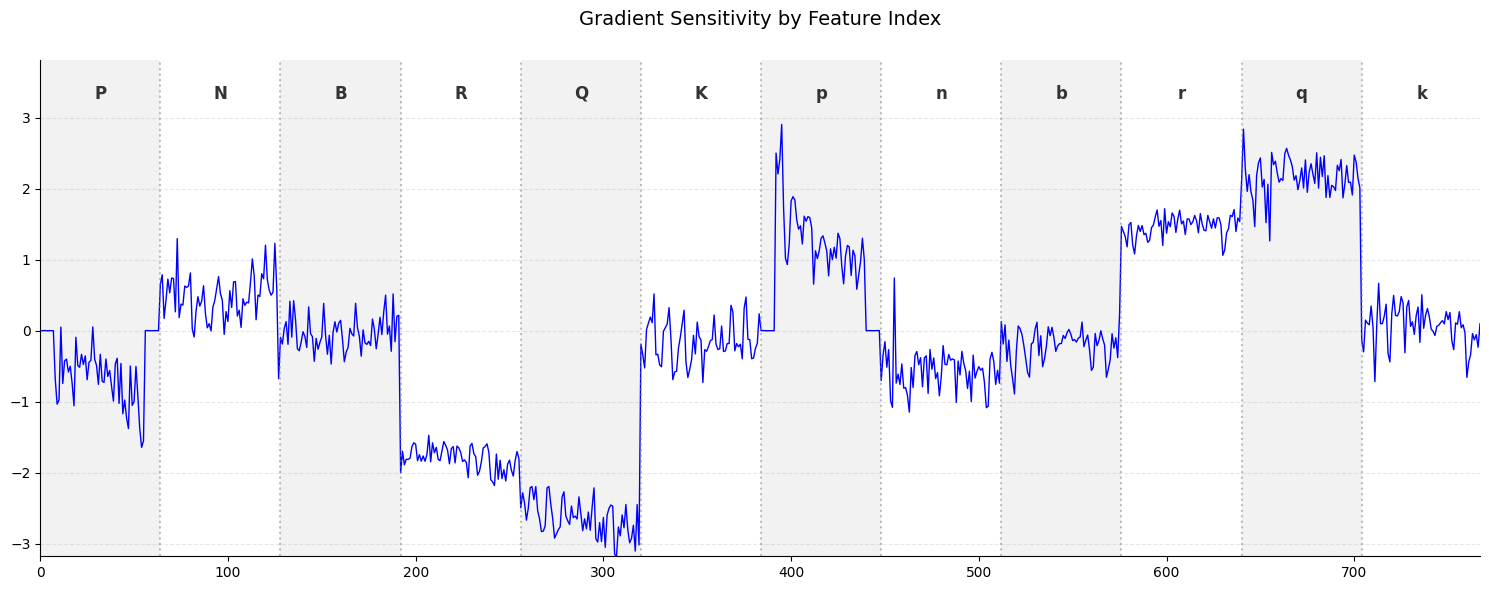


--- CNN Gradients ---


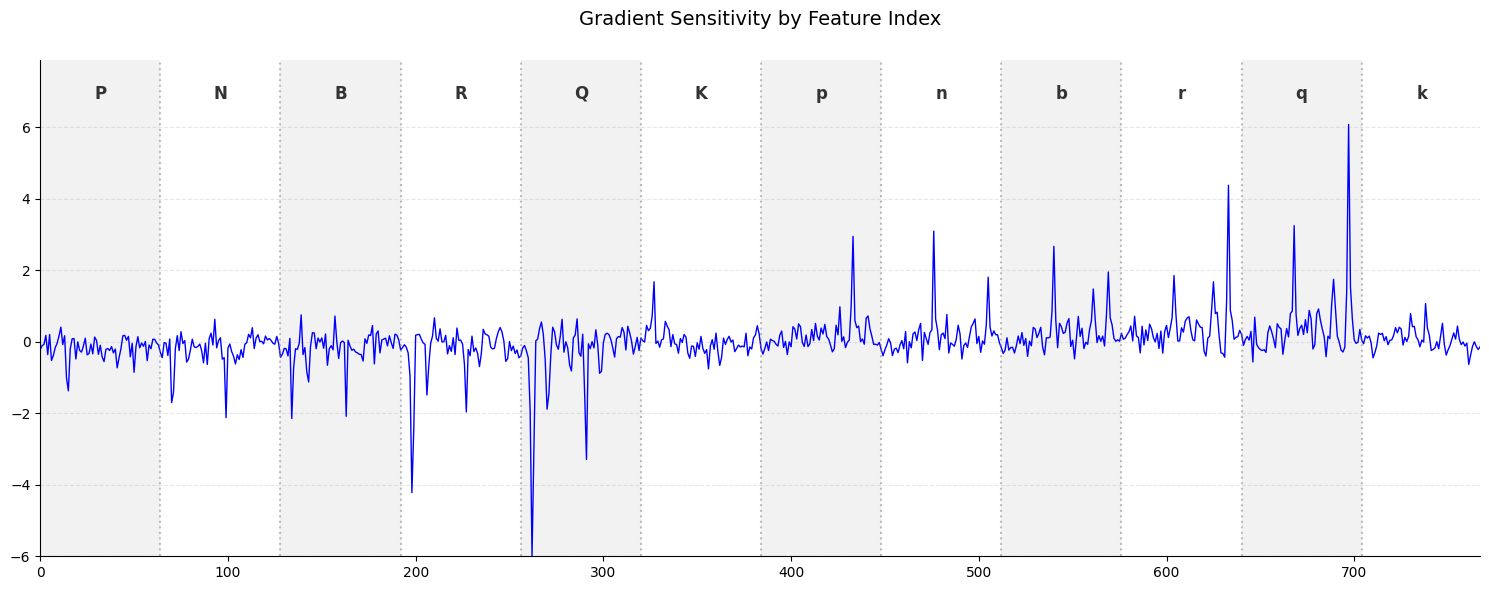


--- TRANSFORMER_4H Gradients ---


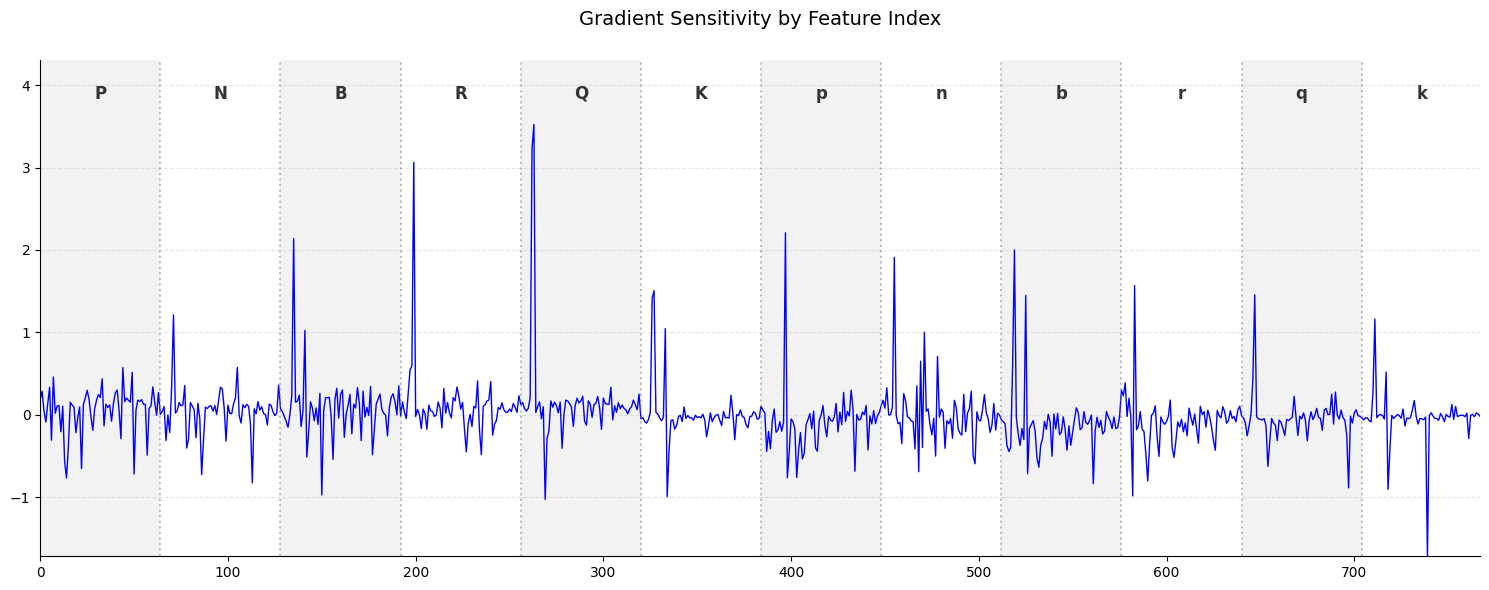

In [189]:
saliency_svgs = []
saliency_titles = []

for model_key, ctx in evaluation_context.items():
    saliency_ext = SaliencyExtractor(ctx["model"])
    grads = saliency_ext.generate_saliency(ctx["X_input"], ctx["pred_label"])
    
    if Config.SHOW_GRADIENTS:
        print(f"\n--- {model_key} Gradients ---")
        plot_chess_gradients(grads)
        
    save_name = f"{ctx['setup']['name']}_saliency"
    title = f"{model_key}<br>(Pred: {ctx['pred_label']})"
    
    svg = plot_chess_saliency_map(
        grads, fen, true_label, ctx["pred_label"], 
        save_name, save_visuals=False, display_svg=False
    )
    saliency_svgs.append(svg)
    saliency_titles.append(title)

display_side_by_side(saliency_svgs, saliency_titles)


Interpretability: MLP
Not applicable.

Interpretability: CNN

--- Grad-CAM Board (True: 0 | Pred: 4) ---


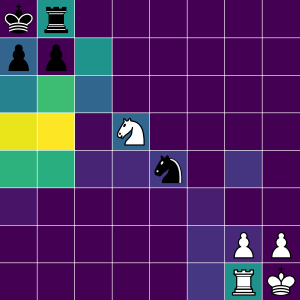

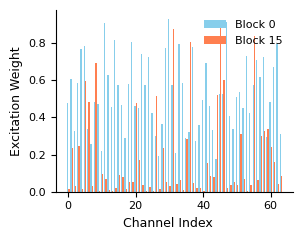


Interpretability: TRANSFORMER_4H
Transformer Attention | Layer 0 | Square: C6


In [190]:
# ==========================================
# Grad-CAM and SE Weights Visualization
# ==========================================
for model_key, ctx in evaluation_context.items():
    model = ctx["model"]
    X_input = ctx["X_input"]
    pred_label = ctx["pred_label"]
    save_name = f"{ctx['setup']['name']}_interp"
    
    print(f"\n{'='*50}\nInterpretability: {model_key}\n{'='*50}")
    
    if "CNN" in model_key:    
        grad_vis = GradCamVisualizer(model)
        plot_gradcam(grad_vis, X_input, fen, true_label, pred_label, save_name, save_visuals=False)
        
        se_ext = SEExtractor(model)
        plot_se_weights(se_ext, X_input, save_name, save_visuals=False)

    elif "TRANSFORMER" in model_key:
        target_square_idx = chess.parse_square("c6") 
        attn_ext = TransformerAttentionExtractor(model)
        
        plot_transformer_attention(
            extractor=attn_ext, 
            input_tensor=X_input, 
            fen=fen, 
            piece_square_index=target_square_idx, 
            layer_idx=0, 
            save_name=save_name, 
            save_visuals=False
        )
        
    elif "MLP" in model_key:
        print(f"Not applicable.")

In [187]:
# ==========================================
# Create failure analysis dataframe
# ==========================================
csv_filename = "master_predictions.csv"
models_to_test = ["MLP", "CNN", "TRANSFORMER_4H"]
loaded_models = {}

for model_key in models_to_test:
    setup = MODEL_REGISTRY[model_key]
    if model_key == "CNN":
        model = SEResNet(in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0)
    elif model_key == "MLP":
        model = MLP(775, 7)
    elif model_key == "TRANSFORMER_4H":
        model = Transformer(input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7)

    model_path = MODEL_DIR / f"{setup['name']}.pth"
    model.load_state_dict(torch.load(model_path))
    model.to(DEVICE)
    model.eval()
    loaded_models[model_key] = model

if Path(csv_filename).exists():
    print(f"'{csv_filename}' already exists! Skipping inference...")
else:
    print(f"'{csv_filename}' not found. Running inference on models...")
    bitmaps_dataset = ChessDataset(root_dir=Path("./dataset_bitmaps_cp/"), split="test")
    planes_dataset = ChessDataset(root_dir=Path("./dataset_planes_cp/"), split="test")

    results = []
    NUM_SAMPLES = len(planes_dataset)

    print(f"Running inference on {NUM_SAMPLES} positions...")
    with torch.no_grad():
        for idx in tqdm(range(NUM_SAMPLES), desc="Generating Predictions"):
            X_planes, y_label = planes_dataset[idx]
            X_bitmaps, _ = bitmaps_dataset[idx]
            
            true_label = y_label.item()
            
            fen = tensor_to_fen(X_planes.numpy())
            
            input_3d = X_planes.unsqueeze(0).to(DEVICE)
            input_1d = X_bitmaps.unsqueeze(0).to(DEVICE) 
            
            row = {
                'index': idx,
                'fen': fen,
                'true_label': true_label
            }

            row['MLP_pred'] = torch.argmax(loaded_models['MLP'](input_1d), dim=1).item()
            row['CNN_pred'] = torch.argmax(loaded_models['CNN'](input_3d), dim=1).item()
            row['TRANSFORMER_4H_pred'] = torch.argmax(loaded_models['TRANSFORMER_4H'](input_3d), dim=1).item()
            
            results.append(row)

    df = pd.DataFrame(results)
    df.to_csv("master_predictions.csv", index=False)
    print(f"DataFrame built with {len(df)} rows!")

'master_predictions.csv' already exists! Skipping inference...


In [115]:
csv_filename = "master_predictions.csv"
df = pd.read_csv(csv_filename)
print(f"Successfully loaded {len(df)} rows!\n")

cnn_blindspots = df[
    (df['TRANSFORMER_4H_pred'] == df['true_label']) & 
    (abs(df['CNN_pred'] - df['true_label']) >= 6)
]

transformer_blindspots = df[
    (df['CNN_pred'] == df['true_label']) & 
    (abs(df['TRANSFORMER_4H_pred'] - df['true_label']) >= 6)
]

mlp_blindspots = df[
    (df['TRANSFORMER_4H_pred'] == df['true_label']) & 
    (df['CNN_pred'] == df['true_label']) & 
    (abs(df['MLP_pred'] - df['true_label']) >= 3)
]

print("--- SYSTEMATIC FAILURE ANALYSIS ---")
print(f"Found {len(cnn_blindspots)} catastrophic CNN failures.")
print(f"Found {len(transformer_blindspots)} catastrophic Transformer failures.")
print(f"Found {len(mlp_blindspots)} catastrophic MLP failures.")

print("\nFirst 5 CNN Blindspot Indices:")
print(cnn_blindspots['index'].head(10).tolist())

print("\First 5 Transformer Blindspot Indices:")
print(transformer_blindspots['index'].tail(50).tolist())

print("\First 5 MLP Blindspot Indices:")
print(mlp_blindspots['index'].head(5).tolist())

Successfully loaded 593047 rows!

--- SYSTEMATIC FAILURE ANALYSIS ---
Found 215 catastrophic CNN failures.
Found 111 catastrophic Transformer failures.
Found 12091 catastrophic MLP failures.

First 5 CNN Blindspot Indices:
[105, 509, 2074, 5600, 7481, 7489, 7690, 8520, 8583, 9911]
\First 5 Transformer Blindspot Indices:
[513370, 516123, 519180, 523193, 525488, 526079, 526949, 527725, 530606, 536098, 538238, 540333, 542379, 542435, 546505, 547289, 547408, 547944, 548923, 549965, 552364, 552482, 553266, 553348, 553759, 555534, 556650, 557534, 558683, 558948, 562764, 563473, 564737, 565162, 565397, 565675, 569531, 570281, 570751, 570897, 575075, 575246, 576602, 578411, 578636, 578737, 583014, 584233, 586755, 591766]
\First 5 MLP Blindspot Indices:
[38, 41, 74, 99, 117]


In [15]:
# Extract the FEN and predictions for our first targets
target_indices = [105, 411]

for idx in target_indices:
    row = df[df['index'] == idx].iloc[0]
    print(f"\n--- Index {idx} ---")
    print(f"FEN: {row['fen']}")
    print(f"True Label: {row['true_label']}")
    print(f"CNN Pred: {row['CNN_pred']}")
    print(f"Transformer Pred: {row['TRANSFORMER_4H_pred']}")
    print(f"MLP Pred: {row['MLP_pred']}")


--- Index 105 ---
FEN: 8/8/8/8/7k/1R2p3/4pp2/4K3 w - - 0 1
True Label: 0
CNN Pred: 6
Transformer Pred: 0
MLP Pred: 0

--- Index 411 ---
FEN: 5k2/6pp/1P6/2p2p2/5P2/1r3rP1/1R4KP/1R6 b - - 0 1
True Label: 0
CNN Pred: 0
Transformer Pred: 3
MLP Pred: 3


In [ ]:
import chess
import chess.svg
from IPython.display import display, HTML

def visualize_failures(indices, df):
    """
    Takes a list of indices (or a single index) and the master dataframe.
    Displays the chess board alongside the ground truth and model predictions.
    """
    if isinstance(indices, int):
        indices = [indices]

    for idx in indices:
        row_data = df[df['index'] == idx]
        
        if row_data.empty:
            print(f"Index {idx} not found in the DataFrame.")
            continue
            
        row = row_data.iloc[0]
        fen = row['fen']
        true_label = row['true_label']
        cnn_pred = row['CNN_pred']
        tf_pred = row['TRANSFORMER_4H_pred']
        mlp_pred = row['MLP_pred']
        
        board = chess.Board(fen)
        board_svg = chess.svg.board(board, size=300)
        
        html_content = f"""
        <div style="display: flex; align-items: flex-start; gap: 30px; margin-bottom: 30px; padding: 20px; border: 1px solid #e0e0e0; border-radius: 8px; background-color: #fcfcfc;">
            <div>
                {board_svg}
            </div>
            <div style="font-family: sans-serif; font-size: 14px; color: #333;">
                <h3 style="margin-top: 0; color: #111;">Index: {idx}</h3>
                <p style="font-family: monospace; background: #eee; padding: 5px; border-radius: 4px;">{fen}</p>
                <hr style="border: 0; height: 1px; background: #ddd; margin: 15px 0;">
                
                <p><b>Ground Truth:</b> <span style="font-size: 16px; font-weight: bold; color: #2e7d32;">Class {true_label}</span></p>
                
                <p><b>Transformer:</b> Class {tf_pred} 
                    <span style="color: {'red' if tf_pred != true_label else 'green'};">
                    (Δ {abs(true_label - tf_pred)})</span>
                </p>
                
                <p><b>CNN:</b> Class {cnn_pred} 
                    <span style="color: {'red' if cnn_pred != true_label else 'green'};">
                    (Δ {abs(true_label - cnn_pred)})</span>
                </p>
                
                <p><b>MLP:</b> Class {mlp_pred} 
                    <span style="color: {'red' if mlp_pred != true_label else 'green'};">
                    (Δ {abs(true_label - mlp_pred)})</span>
                </p>
            </div>
        </div>
        """
        display(HTML(html_content))

In [191]:
visualize_failures([513370], df)